In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [2]:
!kaggle datasets download -d anku5hk/5-faces-dataset
!unzip 5-faces-dataset.zip -d 5-faces-dataset

Dataset URL: https://www.kaggle.com/datasets/anku5hk/5-faces-dataset
License(s): unknown
100% 13.1M/13.1M [00:00<00:00, 101MB/s] 

Archive:  5-faces-dataset.zip
  inflating: 5-faces-dataset/Five_Faces/gates/gates0.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates1.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates10.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates100.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates101.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates103.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates105.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates106.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates107.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates108.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates109.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates11.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates110.jpg  
  inflating: 5-faces-dataset/Five_Faces/gates/gates1

In [3]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
dataset_path = "5-faces-dataset/Five_Faces"
print(os.listdir(dataset_path))

for cls in os.listdir(dataset_path):
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"  {cls}: {count} images")

['trump', 'modi', 'jack', 'musk', 'gates']
  trump: 144 images
  modi: 142 images
  jack: 134 images
  musk: 137 images
  gates: 137 images


In [19]:
balanced_path = "5-faces-balanced"
IMAGES_PER_CLASS = 120

if os.path.exists(balanced_path):
    shutil.rmtree(balanced_path)

for cls in os.listdir(dataset_path):
    src = os.path.join(dataset_path, cls)
    dst = os.path.join(balanced_path, cls)
    os.makedirs(dst)

    all_imgs = os.listdir(src)
    selected = random.sample(all_imgs, IMAGES_PER_CLASS)

    for img_file in selected:
        shutil.copy(os.path.join(src, img_file), os.path.join(dst, img_file))

print("Done! Images per class after balancing:")
for cls in os.listdir(balanced_path):
    print(f"  {cls}: {len(os.listdir(os.path.join(balanced_path, cls)))}")

Done! Images per class after balancing:
  trump: 120
  modi: 120
  jack: 120
  musk: 120
  gates: 120


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train = datagen.flow_from_directory(
    balanced_path,
    target_size=(224, 224),
    batch_size=32,
    subset="training",
    shuffle=True
)

val = datagen.flow_from_directory(
    balanced_path,
    target_size=(224, 224),
    batch_size=32,
    subset="validation",
    shuffle=False   # important for confusion matrix
)

class_names = list(train.class_indices.keys())
print("Classes:", class_names)

Found 480 images belonging to 5 classes.
Found 120 images belonging to 5 classes.
Classes: ['gates', 'jack', 'modi', 'musk', 'trump']


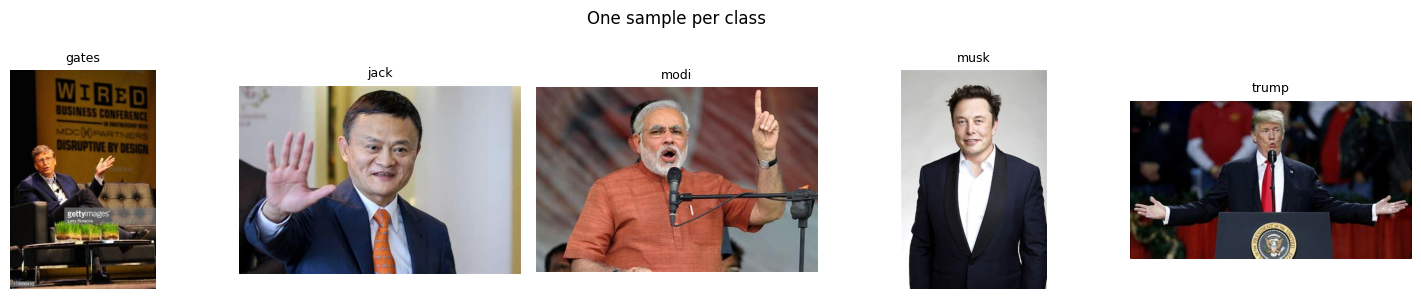

In [21]:
plt.figure(figsize=(15, 3))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(balanced_path, cls)
    img_file = os.listdir(cls_path)[0]
    img_arr  = plt.imread(os.path.join(cls_path, img_file))
    plt.subplot(1, 5, i+1)
    plt.imshow(img_arr)
    plt.title(cls, fontsize=9)
    plt.axis('off')
plt.suptitle('One sample per class', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Fine-tune: freeze all layers except last 25
base_model.trainable = True
for layer in base_model.layers[:-25]:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,526,533 (5.82 MB)

 Non-trainable params: 896,064 (3.42 MB)

In [23]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3292 - loss: 1.7034 - val_accuracy: 0.3500 - val_loss: 1.4830
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 475ms/step - accuracy: 0.6396 - loss: 0.9925 - val_accuracy: 0.4250 - val_loss: 1.3521
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 528ms/step - accuracy: 0.8000 - loss: 0.6498 - val_accuracy: 0.5583 - val_loss: 1.1709
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 447ms/step - accuracy: 0.8938 - loss: 0.4312 - val_accuracy: 0.6083 - val_loss: 1.0805
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 528ms/step - accuracy: 0.9125 - loss: 0.3267 - val_accuracy: 0.6333 - val_loss: 1.0280
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 448ms/step - accuracy: 0.9250 - loss: 0.2573 - val_accuracy: 0.6833 - val_loss: 1.0012
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 519ms/step - accuracy: 0.9646 - loss: 0.1705 - val_accuracy: 0.7833 - val_loss: 0.7781
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 534ms/step - accuracy: 0.9688 - loss: 0.1412 - val_accuracy: 0.73

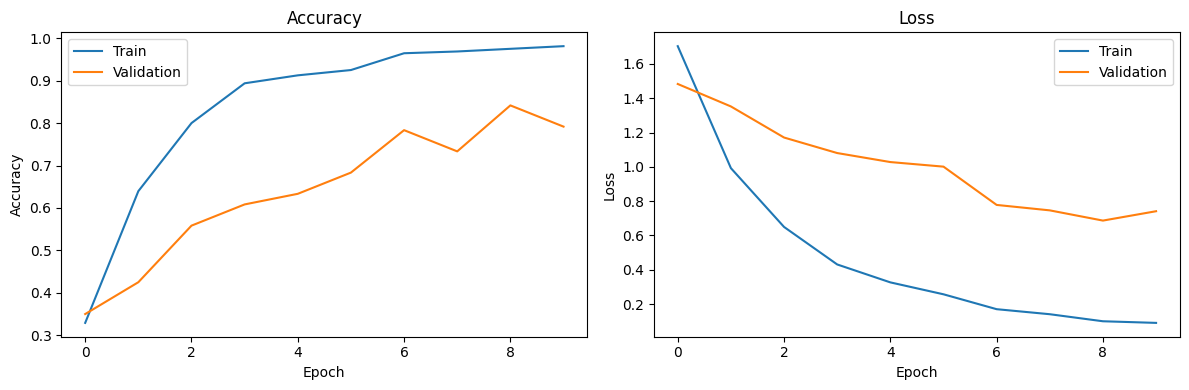

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
loss, acc = model.evaluate(val)
print(f"Validation Accuracy: {acc*100:.2f}%")
print(f"Validation Loss    : {loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 850ms/step - accuracy: 0.8083 - loss: 0.7652
Validation Accuracy: 80.83%
Validation Loss    : 0.7652


4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


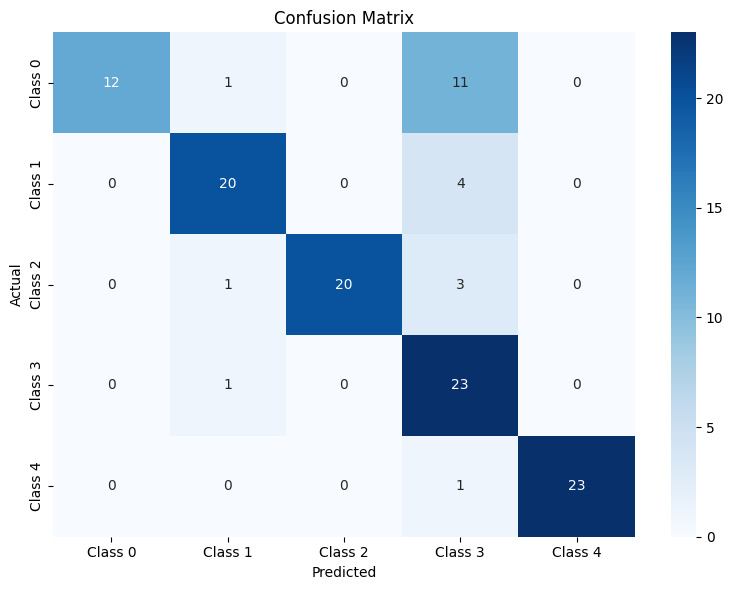

              precision    recall  f1-score   support

     Class 0       1.00      0.50      0.67        24
     Class 1       0.87      0.83      0.85        24
     Class 2       1.00      0.83      0.91        24
     Class 3       0.55      0.96      0.70        24
     Class 4       1.00      0.96      0.98        24

    accuracy                           0.82       120
   macro avg       0.88      0.82      0.82       120
weighted avg       0.88      0.82      0.82       120



In [26]:
val.reset()

y_pred = np.argmax(model.predict(val), axis=1)
y_true = val.classes

# Custom class labels
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


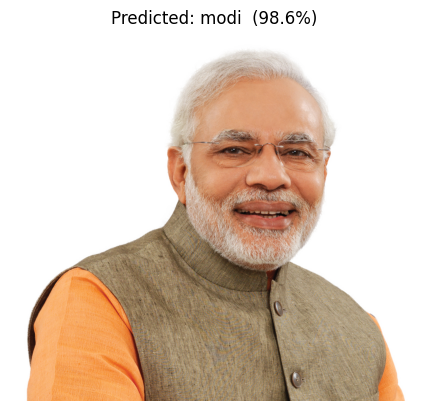

Prediction: modi
Confidence: 98.6%


In [27]:
from tensorflow.keras.preprocessing import image as keras_image

img_path = "/content/images (1).jpg"

img = keras_image.load_img(img_path, target_size=(224, 224))
img_array = keras_image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.imshow(keras_image.load_img(img_path))
plt.title(f"Predicted: {predicted_class}  ({confidence:.1f}%)")
plt.axis('off')
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.1f}%")

In [28]:
model.save("model_1.h5")
print("Model saved as model_1.h5")

Model saved as model_1.h5


In [29]:
model.save("model_1.keras")
print("Model saved as model_1.keras")

Model saved as model_1.keras
